In [57]:
# Load the libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sea

sea.set(style="whitegrid")

In [58]:
# Load the csv dataset
df = pd.read_csv(r"D:\Movies\Week 2 Task\train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [59]:
# Label of the columns
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [60]:
# Physical View
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [61]:
# Missing values and Duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows: ", df.duplicated().sum())

Missing values per column:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows:  0


In [62]:
# Convert Date columns
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"], dayfirst=True, errors="coerce")
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"], dayfirst=True, errors="coerce")

df_clean[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [63]:
# Seperating Month and Year for Visulaizations wrt Months
df_clean["Month"] = df_clean["Order Date"].dt.to_period("M")
df_clean[["Order Date", "Month"]].head()

,Order Date,Month
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


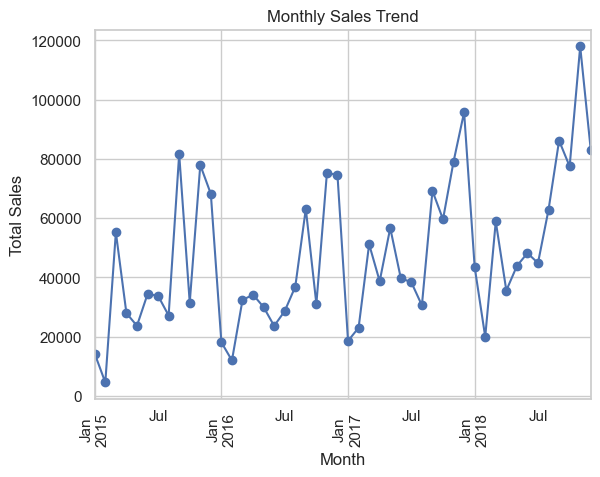

In [64]:
# Monthly Sales
monthly_sales = df_clean.groupby("Month")["Sales"].sum()
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

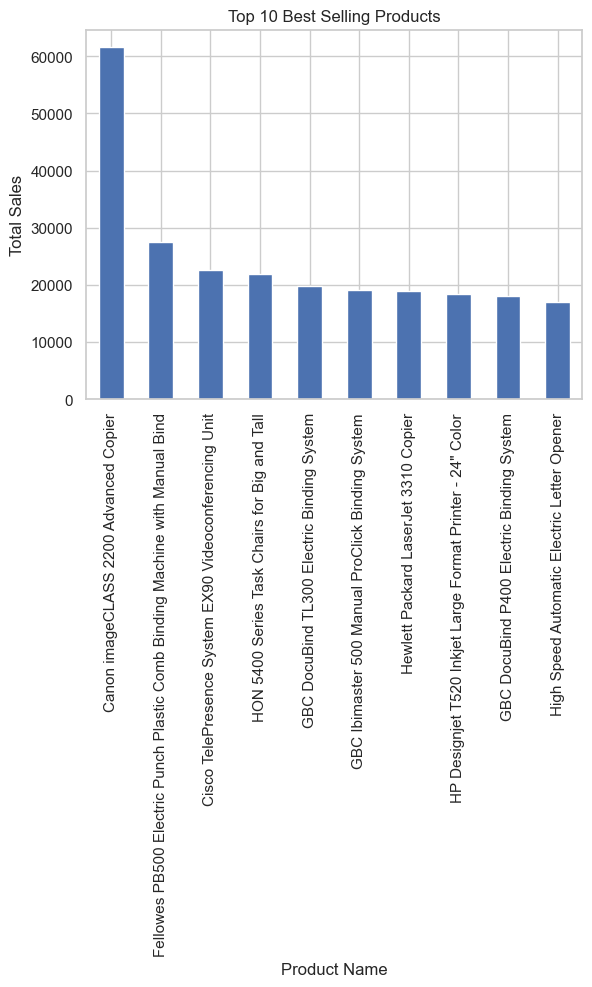

In [65]:
# Top 10 Products by Sales
top_products = df_clean.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")
plt.title("Top 10 Best Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

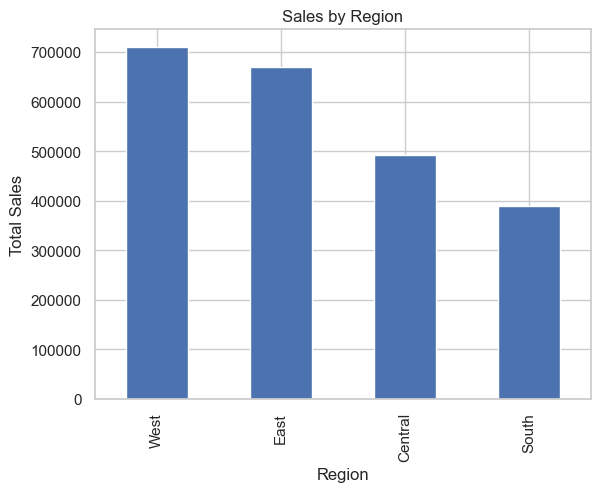

In [66]:
# Region Wise Sales
region_sales = df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()


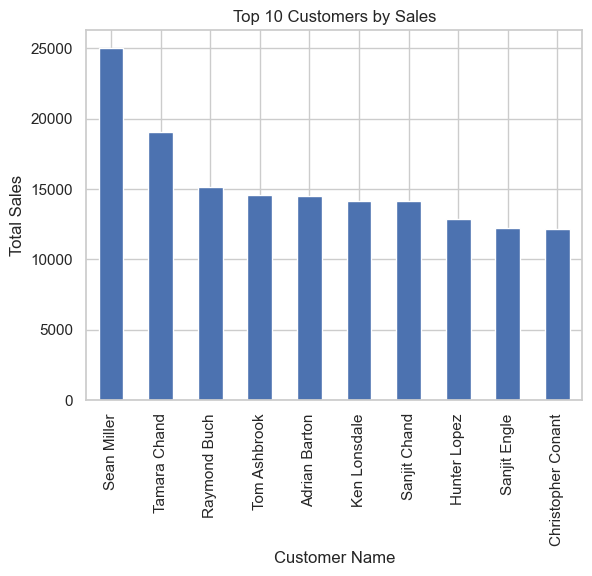

In [67]:
# Top 10 Customers
top_customers = df_clean.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

In [68]:
# Final Summary
print("Sales Summary")
print("\n")
print("Dataset Shape:", df_clean.shape)
print("Total Sales:", df_clean["Sales"].sum())
print("Average Sales:", df_clean["Sales"].mean())

print("\nTop 5 Products:")
print(df_clean.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(5))

print("\nTop Region:")
print(df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False).head(1))

print("\nTop Category:")
print(df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False).head(1))

Sales Summary


Dataset Shape: (9800, 19)
Total Sales: 2261536.7827
Average Sales: 230.76905945918367

Top 5 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Top Region:
Region
West    710219.6845
Name: Sales, dtype: float64

Top Category:
Category
Technology    827455.873
Name: Sales, dtype: float64
